# Analysis of HKAN

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import itertools
import tqdm
import numpy as np
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Ridge
import importlib
import hkan
from hkan import ( 
    Sigmoid, Gaussian, ReLU, Tanh, Softplus, Identity, make_centers, # type: ignore
    make_hkan_layer, set_tqdm_disable, extend_hkan, apply_basis_fn # type: ignore
)
from datasets import load_dataset

## Debugging the code

In [2]:
# Create X, y sets for debugging
X = np.vstack([np.linspace(0, 1, 10), np.linspace(1, 2, 10)]).T  # shape (10,2)
y = X.sum(axis=1) * 2
n_samples_, n_vars_in_ = X.shape
n_vars_out_ = 2
n_basis_ = 3
centers = "random_data_points"
basis_fn = ReLU(s=1)

In [3]:
y

array([2.        , 2.44444444, 2.88888889, 3.33333333, 3.77777778,
       4.22222222, 4.66666667, 5.11111111, 5.55555556, 6.        ])

In [4]:
# Create centers using the selected center method
print("Shape of X: ", X.shape)
print("Shape of y: ", y.shape)
centers_arr_ = make_centers(
    n_vars_out=n_vars_out_, # number of hidden layer nodes
    n_vars_in=n_vars_in_, # number of input features
    n_basis=n_basis_, # each edge has 3 basis functions
    centers=centers,
    X=X
)
print("Shape of Centers: ", centers_arr_.shape)
print(f"[Center method: {centers}]: Sample centers on an example edge 0, 0:", centers_arr_[0, 0, :])

Shape of X:  (10, 2)
Shape of y:  (10,)
Shape of Centers:  (2, 2, 3)
[Center method: random_data_points]: Sample centers on an example edge 0, 0: [0.88888889 0.77777778 0.88888889]


In [5]:
centers_arr_[0] # the first node in the hidden layer

array([[0.88888889, 0.77777778, 0.88888889],
       [1.11111111, 1.11111111, 1.22222222]])

In [6]:
centers_arr_[0, 0] # edge connects first node of input layer with the first node of hidden layer

array([0.88888889, 0.77777778, 0.88888889])

In [7]:
# Expanding Layer
# Debugging: FIT
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
base_regressor = LinearRegression(fit_intercept=False) # centered, pass through origin
MININTERVAL = 0.1
TQDM_DISABLE = False
# For each edge, there is one regression model to train
models = []
for q, p in tqdm.tqdm(
    # number of steps = number of edges
    itertools.product(range(n_vars_out_), range(n_vars_in_)),
    desc="Fitting 1D regressors",
    total=n_vars_out_ * n_vars_in_,
    mininterval=MININTERVAL,
    disable=TQDM_DISABLE,
):  # on each edge compute transformation for input values
    transformed_features = apply_basis_fn(
        X, centers_arr_, basis_fn, q, p
    )
    # then fit the regression model
    reg = clone(base_regressor).fit(transformed_features, y)
    models.append((q, p, reg))

Fitting 1D regressors: 100%|██████████| 4/4 [00:00<00:00, 215.69it/s]


In [8]:
# Each edge has its own linear regression without interception
models

[(0, 0, LinearRegression(fit_intercept=False)),
 (0, 1, LinearRegression(fit_intercept=False)),
 (1, 0, LinearRegression(fit_intercept=False)),
 (1, 1, LinearRegression(fit_intercept=False))]

In [9]:
centers_arr_

array([[[0.88888889, 0.77777778, 0.88888889],
        [1.11111111, 1.11111111, 1.22222222]],

       [[0.77777778, 1.        , 1.        ],
        [1.22222222, 1.88888889, 1.44444444]]])

In [10]:
X

array([[0.        , 1.        ],
       [0.11111111, 1.11111111],
       [0.22222222, 1.22222222],
       [0.33333333, 1.33333333],
       [0.44444444, 1.44444444],
       [0.55555556, 1.55555556],
       [0.66666667, 1.66666667],
       [0.77777778, 1.77777778],
       [0.88888889, 1.88888889],
       [1.        , 2.        ]])

In [11]:
transformed_features

array([[0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.11111111, 0.        , 0.        ],
       [0.22222222, 0.        , 0.        ],
       [0.33333333, 0.        , 0.11111111],
       [0.44444444, 0.        , 0.22222222],
       [0.55555556, 0.        , 0.33333333],
       [0.66666667, 0.        , 0.44444444],
       [0.77777778, 0.11111111, 0.55555556]])

In [12]:
transformed_features.shape

(10, 3)

In [13]:
# Expanding Layer
# Debugging: TRANSFORM

out = np.empty((n_vars_out_, n_vars_in_, n_samples_))

for q, p, model in models:
    transformed_features = apply_basis_fn(
        X, centers_arr_, basis_fn, q, p
    )
    # predictions of each edge
    out[q, p, :] = model.predict(transformed_features)


In [14]:
transformed_features

array([[0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.11111111, 0.        , 0.        ],
       [0.22222222, 0.        , 0.        ],
       [0.33333333, 0.        , 0.11111111],
       [0.44444444, 0.        , 0.22222222],
       [0.55555556, 0.        , 0.33333333],
       [0.66666667, 0.        , 0.44444444],
       [0.77777778, 0.11111111, 0.55555556]])

In [15]:
print(out.shape)
out

(2, 2, 10)


array([[[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 5.55555556, 6.        ],
        [0.        , 0.        , 2.88888889, 3.33333333, 3.77777778,
         4.22222222, 4.66666667, 5.11111111, 5.55555556, 6.        ]],

       [[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 3.51111111, 7.02222222],
        [0.        , 0.        , 0.        , 2.07729469, 4.15458937,
         4.47342995, 4.79227053, 5.11111111, 5.42995169, 6.        ]]])

In [16]:
# Connecting Layer
# Debugging: Fit
connecting_base_regressor = LinearRegression(fit_intercept=True) # now adding bias matters
connecting_models = []
for q in tqdm.tqdm(
    # Fit Linear Regression model for each node
    range(n_vars_out_),
    desc="Fitting connecting regressors",
    total=n_vars_out_,
    mininterval=MININTERVAL,
    disable=TQDM_DISABLE,
):
    reg = clone(connecting_base_regressor).fit(out[q, :, :].T, y)
    connecting_models.append((q, reg))

Fitting connecting regressors: 100%|██████████| 2/2 [00:00<00:00, 977.35it/s]


In [17]:
out.shape[2]

10

In [18]:
# Each node has its own Linear Regression model
connecting_models

[(0, LinearRegression()), (1, LinearRegression())]

In [19]:
y

array([2.        , 2.44444444, 2.88888889, 3.33333333, 3.77777778,
       4.22222222, 4.66666667, 5.11111111, 5.55555556, 6.        ])

In [20]:
# Connecting Layer
# Debugging: Transform
preds = np.empty((n_vars_out_, out.shape[2]))

for q, reg in connecting_models:
    preds[q, :] = reg.predict(out[q, :, :].T)

preds.T
# add one more connecting layer with n_vars_out_ = 1

array([[2.00970185, 2.40643646],
       [2.00970185, 2.40643646],
       [3.49758707, 2.40643646],
       [3.72649248, 3.34339288],
       [3.9553979 , 4.2803493 ],
       [4.18430332, 4.42416121],
       [4.41320874, 4.56797313],
       [4.64211415, 4.71178504],
       [5.63570615, 5.35050259],
       [5.92578649, 6.10252649]])

## Paper Analysis - Assumptions

In [21]:
data = load_dataset("TF5")
X_train, X_test, y_train, y_test = data["train_input"], data["test_input"], data["train_label"], data["test_label"]
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5000, 2), (10000, 2), (5000,), (10000,))

### A.1. HKAN depth = stability, not expressivity

The first HKAN layer already captures most of the global structure, while additional layers mainly help stabilize the approximation and reduce variance rather than learning fundamentally new patterns

In [22]:
import matplotlib.pyplot as plt

def plot_model_comparison_3d(
    X,
    y,
    model1,
    model2,
    model1_title="Model 1",
    model2_title="Model 2",
    cmap="viridis"
):
    """
    Plots 3D surfaces for:
    - model1 prediction
    - model2 prediction
    - ground truth

    Assumes X forms a 100x100 grid.
    """

    # Predictions
    y_pred_1 = model1.predict(X)
    y_pred_2 = model2.predict(X)

    # Fixed grid reshape
    X1 = X[:, 0].reshape(100, 100)
    X2 = X[:, 1].reshape(100, 100)

    Y1 = y_pred_1.reshape(100, 100)
    Y2 = y_pred_2.reshape(100, 100)
    Yt = y.reshape(100, 100)

    # Calculate rmse
    model1_rmse = root_mean_squared_error(y_test, y_pred_1)
    model2_rmse = root_mean_squared_error(y_test, y_pred_2)
    print(f"Model 1 - RMSE: {model1_rmse:g}")
    print(f"Model 2 - RMSE: {model2_rmse:g}")

    # Shared z-limits
    zmin = min(Y1.min(), Y2.min(), Yt.min())
    zmax = max(Y1.max(), Y2.max(), Yt.max())

    fig = plt.figure(figsize=(18, 6))

    # Model 1
    ax = fig.add_subplot(131, projection="3d")
    ax.plot_surface(X1, X2, Y1, cmap=cmap)
    ax.set_title(model1_title)
    ax.set_zlim(zmin, zmax)

    # Model 2
    ax = fig.add_subplot(132, projection="3d")
    ax.plot_surface(X1, X2, Y2, cmap=cmap)
    ax.set_title(model2_title)
    ax.set_zlim(zmin, zmax)

    # Actual
    ax = fig.add_subplot(133, projection="3d")
    ax.plot_surface(X1, X2, Yt, cmap=cmap)
    ax.set_title("Actual")
    ax.set_zlim(zmin, zmax)

    plt.tight_layout()
    plt.show()


#### Case1:

* model 1: 1 layer, center method: random_data_points 
* model 2: 2 layer, center method: random (uniform) -> random_data_points

In [23]:
set_tqdm_disable(False)
# 1 layer model
model_1_l = make_hkan_layer(
    layer_idx=0,
    n_vars_out=1,
    basis_fn=Tanh(s=50),  # type: ignore
    n_basis=23,
    centers="random_data_points",
    expanding_base_regressor=Ridge(alpha=0.01),
)
model_1_l.fit(X_train, y_train)
y_pred_1_l = model_1_l.predict(X_test)
model_1_l

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00, 1148.18it/s]


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,1
,n_basis,23
,centers,'random_data_points'
,basis_fn,<hkan.Tanh ob...t 0x13fc16a90>
,base_regressor,Ridge(alpha=0.01)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [24]:
# 2 layer model
model = make_hkan_layer(
    layer_idx=0,
    n_vars_out=912,
    basis_fn=Tanh(s=50), # type: ignore
    n_basis=23,
    centers="random",
    expanding_base_regressor=Ridge(alpha=0.01),
)

model_2_l = extend_hkan(
    model,
    layer_idx=1,
    n_vars_out=1,
    basis_fn=Identity(), # type: ignore
    centers="random_data_points",
    expanding_base_regressor=Ridge(alpha=0.1),
)
model_2_l.fit(X_train, y_train)
y_pred_2_l = model_2_l.predict(X_test)
model_2_l


Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  3.07it/s]


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,912
,n_basis,23
,centers,'random'
,basis_fn,<hkan.Tanh ob...t 0x16954ba10>
,base_regressor,Ridge(alpha=0.01)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


Model 1 - RMSE: 0.0452523
Model 2 - RMSE: 9.25987e-13


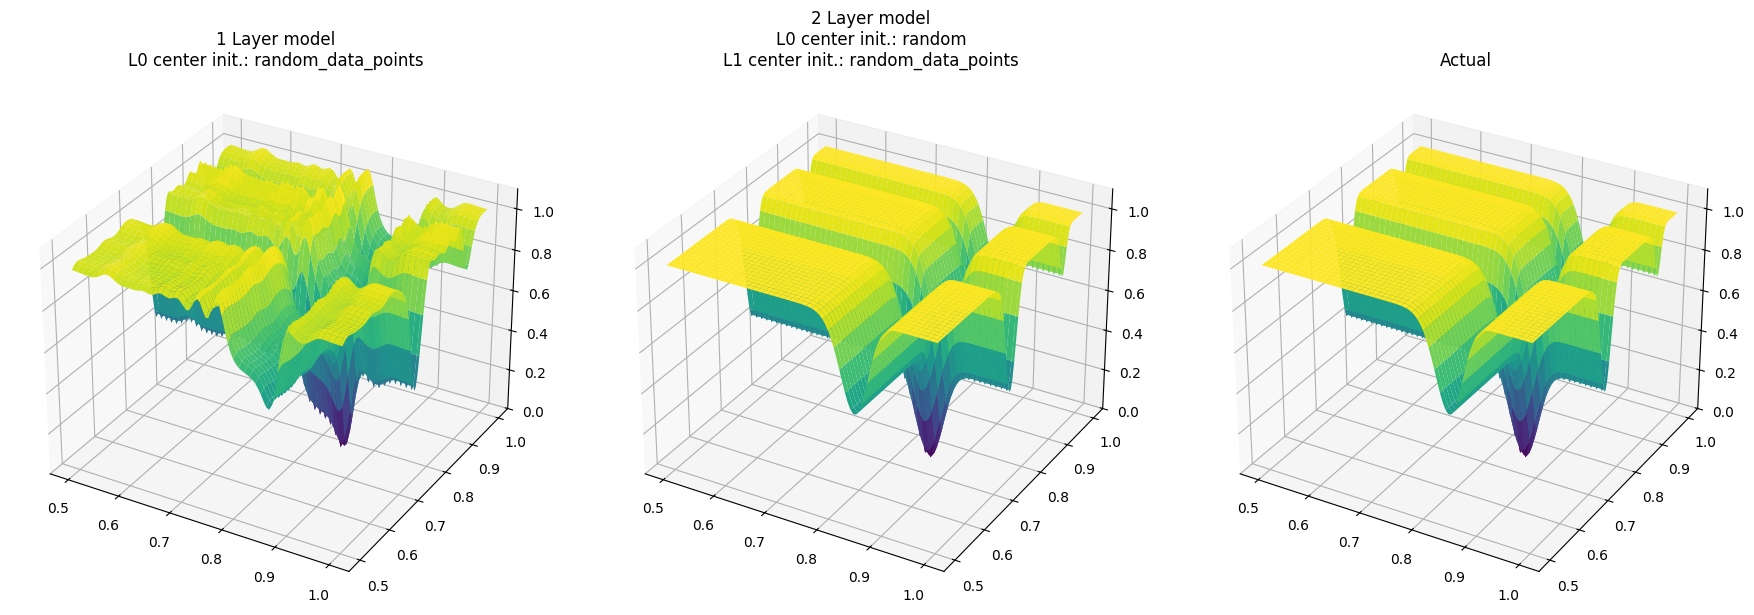

In [25]:
plot_model_comparison_3d(
    X_test,
    y_test,
    model1=model_1_l,
    model2=model_2_l,
    model1_title="1 Layer model\nL0 center init.: random_data_points",
    model2_title="2 Layer model\nL0 center init.: random\nL1 center init.: random_data_points"
)

#### Case2:

* model 1: 1 layer, center method: random (uniform) 
* model 2: 2 layer, center method: random (uniform) -> random_data_points

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00, 1212.23it/s]


Model 1 - RMSE: 0.108235
Model 2 - RMSE: 9.25987e-13


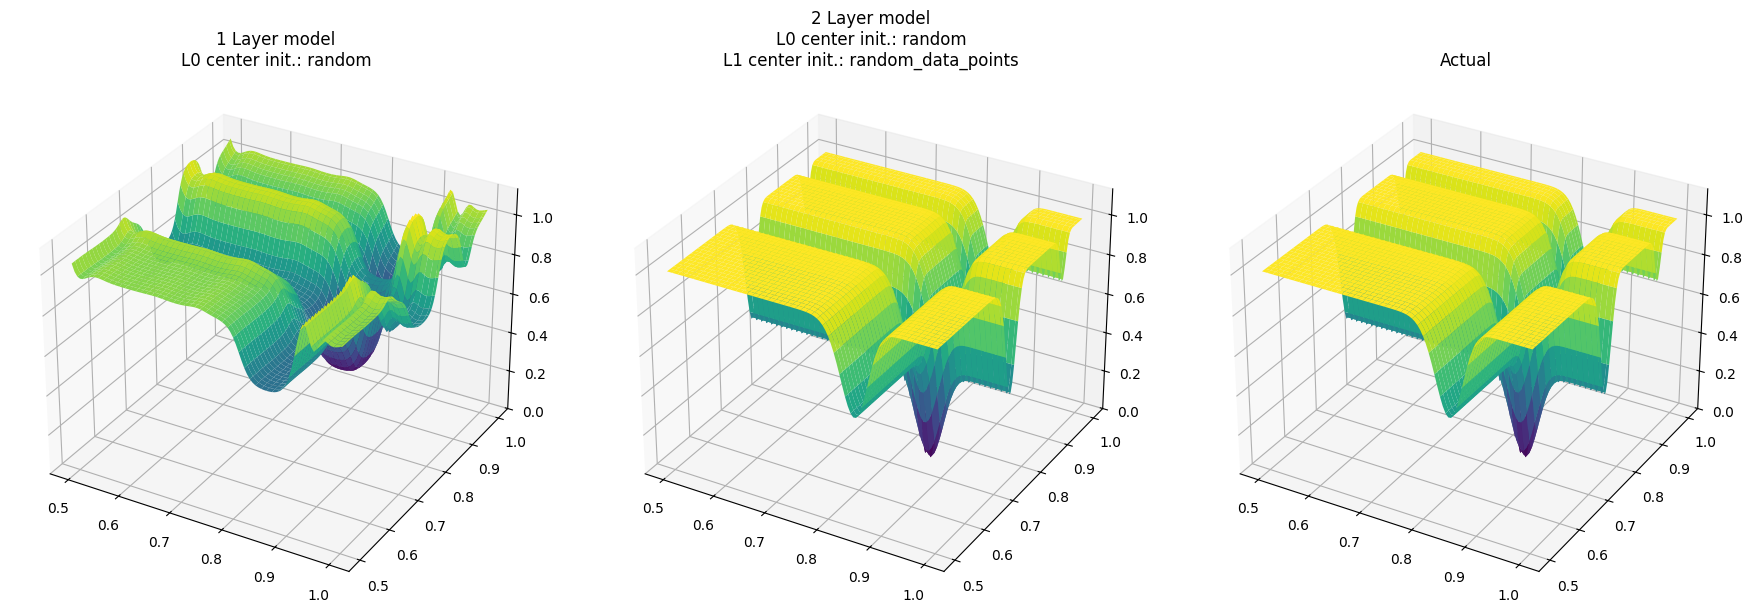

In [26]:
model_1_l_n = make_hkan_layer(
    layer_idx=0,
    n_vars_out=1,
    basis_fn=Tanh(s=50),  # type: ignore
    n_basis=23,
    centers="random", # it is not reliable changes a lot.
    expanding_base_regressor=Ridge(alpha=0.01),
)
model_1_l_n.fit(X_train, y_train)
plot_model_comparison_3d(
    X_test,
    y_test,
    model1=model_1_l_n,
    model2=model_2_l,
    model1_title="1 Layer model\nL0 center init.: random",
    model2_title="2 Layer model\nL0 center init.: random\nL1 center init.: random_data_points"
)


* No new modes, ridges, or valleys appear
* **random_data_points** is better than **random** for 1-layer network, and this might be a reason for smart sampling might work.
* The model is not becoming more expressive in a compositional sense
* This improves RMSE, but without changing the function’s global shape since it already uses the predictions from the previous layer

### A.2. Hyper-parameter Selection

Finding parameters for the other benchmark datasets

In [27]:
# ...existing code...
def build_hkan_from_params(model_params, tqdm_disable=True):
    """
    Build an HKAN model from a list of layer-param dicts.
    """
    # ensure sorted by layer index
    params = sorted(model_params, key=lambda p: int(p["layer"]))
    model = None
    set_tqdm_disable(tqdm_disable)  # keep consistent with notebook usage

    for p in params:
        layer_idx = int(p["layer"])
        n_vars_out = p["n_vars_out"]
        basis_fn = p["basis_fn"]
        n_basis = p.get("n_basis", None)
        centers = p.get("centers", "random")
        reg = p.get("regressor", Ridge())

        if layer_idx == 0:
            model = make_hkan_layer(
                layer_idx=layer_idx,
                n_vars_out=n_vars_out,
                basis_fn=basis_fn,
                n_basis=n_basis,
                centers=centers,
                expanding_base_regressor=reg,
            )
        else:
            if model is None:
                raise ValueError("First layer (layer 0) must be provided before extending.")
            model = extend_hkan(
                model,
                layer_idx=layer_idx,
                n_vars_out=n_vars_out,
                basis_fn=basis_fn,
                n_basis=n_basis,
                centers=centers,
                expanding_base_regressor=reg,
            )
    return model

In [28]:
model_params = [
    {
        "layer": 0,
        "n_vars_out": 912,
        "basis_fn": Tanh(s=50),
        "n_basis": 23,
        "centers": "random",
        "regressor": Ridge(alpha=0.01),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        "n_basis": 10,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=0.1),
    },
    # {
    #     "layer": 2,
    #     "n_vars_out": 1,
    #     "basis_fn": Identity(),
    #     "n_basis": None,
    #     "centers": "random_data_points",
    #     "regressor": Ridge(alpha=0.1),
    # },
]
# Example usage:
model = build_hkan_from_params(model_params)
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,912
,n_basis,23
,centers,'random'
,basis_fn,<hkan.Tanh ob...t 0x16af31850>
,base_regressor,Ridge(alpha=0.01)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [29]:
if model:
    model.fit(X_train, y_train)

In [30]:
if model:
    y_hat = model.predict(X_test)
    print(root_mean_squared_error(y_test, y_hat))

3.3319828207745824e-13
